# **INTRODUCTION**
- The project utilizes the Online Retail II dataset, sourced from the UCI Machine Learning Repository.

This is a real-world, transactional dataset that captures all activities for a UK-based, registered online retailer.

-  **Temporal Coverage**: The dataset transactions occurring over a two-year period, specifically between December 1, 2009 until December 9, 2011.
-  **Business Context**: The retailer specializes in unique all-occasion giftware, with a significant portion of its clientele consisting of wholesalers.
-  **Dataset Scale**: The data comprises approximately 1.07 million instances (transactions) across eight distinct attributes, making it a robust resource for multivariate, sequential, and time-series analysis.


- The study uses this dataset because:
  - It mirrors real-world retail challenges, such as:
    - **Handling Cancellations**: The presence of 'c' prefixes in InvoiceNo allows for the analysis of return rates and shrinkage.
    - **Wholesale Patterns**: Many customers are wholesalers hence provides a unique opportunity to analyze high-volume purchasing behaviors and B2B pricing strategies.
    - **Analytical Depth**: With over a million rows, it is an excellent source to show data processing using tools like PySpark and Polars.  

In [294]:
#spark.stop()

In [169]:
import pandas as pd
import polars as pl
import os
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import re

from pyspark.sql import functions as F
from pyspark.sql.window import Window

In [170]:
import urllib.request

url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
urllib.request.urlretrieve(url, "online_retail_ii.zip")

('online_retail_ii.zip', <http.client.HTTPMessage at 0x1514a5cd220>)

In [171]:
#check if file exist

os.path.exists("online_retail_ii.zip")

True

In [172]:
with zipfile.ZipFile("online_retail_ii.zip", "r") as zip_ref:
    zip_ref.extractall("online_retail_ii")

In [173]:
#verify if file exist
os.listdir("online_retail_ii")

['online_retail.parquet', 'online_retail_II.xlsx']

In [174]:
#1. Read the data
excel_path = "online_retail_ii/online_retail_II.xlsx"

# Get sheet names
df_excel = pd.ExcelFile(excel_path)
print(df_excel.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [175]:
#2. Read both sheet, combine and convert them to parquet

df_list = [
    pl.read_excel(
        excel_path,
        sheet_name=sheet,
        infer_schema_length=1000
    )
    for sheet in df_excel.sheet_names
]

# Combine the sheet
df = pl.concat(df_list)

print(df.head())
print(df.shape)

# export to parquet

datapath = r"H:\My Drive\UKM\Sem2\Database management\FinalProject\OnlineRetail_ii\DataAnalysisPython"
df.write_parquet(f"{datapath}/data_onlineretail_ii.parquet")

shape: (5, 8)
┌─────────┬───────────┬────────────────┬──────────┬────────────────┬───────┬─────────────┬─────────┐
│ Invoice ┆ StockCode ┆ Description    ┆ Quantity ┆ InvoiceDate    ┆ Price ┆ Customer ID ┆ Country │
│ ---     ┆ ---       ┆ ---            ┆ ---      ┆ ---            ┆ ---   ┆ ---         ┆ ---     │
│ str     ┆ str       ┆ str            ┆ i64      ┆ datetime[ms]   ┆ f64   ┆ i64         ┆ str     │
╞═════════╪═══════════╪════════════════╪══════════╪════════════════╪═══════╪═════════════╪═════════╡
│ 489434  ┆ 85048     ┆ 15CM CHRISTMAS ┆ 12       ┆ 2009-12-01     ┆ 6.95  ┆ 13085       ┆ United  │
│         ┆           ┆ GLASS BALL 20  ┆          ┆ 07:45:00       ┆       ┆             ┆ Kingdom │
│         ┆           ┆ L…             ┆          ┆                ┆       ┆             ┆         │
│ 489434  ┆ 79323P    ┆ PINK CHERRY    ┆ 12       ┆ 2009-12-01     ┆ 6.75  ┆ 13085       ┆ United  │
│         ┆           ┆ LIGHTS         ┆          ┆ 07:45:00       ┆       ┆ 

In [176]:
#3. Load Data into pyspark
spark = SparkSession.builder \
    .appName("onlineretail_ii") \
    .getOrCreate()

spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

parquet_path = f"{datapath}/data_onlineretail_ii.parquet"

df = spark.read.parquet(parquet_path)

df.head(5)

df.schema

StructType([StructField('Invoice', StringType(), True), StructField('StockCode', StringType(), True), StructField('Description', StringType(), True), StructField('Quantity', LongType(), True), StructField('InvoiceDate', TimestampNTZType(), True), StructField('Price', DoubleType(), True), StructField('Customer ID', LongType(), True), StructField('Country', StringType(), True)])

In [177]:
# Preview data
df.show(10, truncate=False)

+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12      |2009-12-01 07:45:00|6.95 |13085      |United Kingdom|
|489434 |79323P   |PINK CHERRY LIGHTS                 |12      |2009-12-01 07:45:00|6.75 |13085      |United Kingdom|
|489434 |79323W   | WHITE CHERRY LIGHTS               |12      |2009-12-01 07:45:00|6.75 |13085      |United Kingdom|
|489434 |22041    |RECORD FRAME 7" SINGLE SIZE        |48      |2009-12-01 07:45:00|2.1  |13085      |United Kingdom|
|489434 |21232    |STRAWBERRY CERAMIC TRINKET BOX     |24      |2009-12-01 07:45:00|1.25 |13085      |United Kingdom|
|489434 |22064    |PINK DOUGHNUT TRINKET POT          |2

In [178]:
# Check column names
df.columns

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [179]:
# convert Customer ID to CustomerID cause Spark sensitive to whitescape
df = df.withColumnRenamed("Customer ID", "CustomerID")
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp_ntz (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: long (nullable = true)
 |-- Country: string (nullable = true)



In [180]:
# Check misssing value
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+-------+---------+-----------+--------+-----------+-----+----------+-------+
|Invoice|StockCode|Description|Quantity|InvoiceDate|Price|CustomerID|Country|
+-------+---------+-----------+--------+-----------+-----+----------+-------+
|      0|        0|       4382|       0|          0|    0|    243007|      0|
+-------+---------+-----------+--------+-----------+-----+----------+-------+



# Handling Missing Values in Transactional Dataset

## Customer ID
- **[Investigate invoices](ca://s?q=Investigate_invoices_with_missing_Customer_ID)**: Check if invoices with missing Customer IDs also contain rows with valid IDs.  
- **[Infer missing IDs](ca://s?q=Infer_missing_Customer_IDs_from_invoice)**: If a valid Customer ID exists within the same invoice, propagate it to rows where it is missing.  
- **[Retain unrecoverable records](ca://s?q=Retain_records_with_unrecoverable_Customer_IDs)**: If no Customer ID is available for the invoice, keep those rows since they still contain valid transaction details (StockCode, Quantity, Price, Country).

---

## Description
- **[Check data quality](ca://s?q=Check_data_quality_in_Description_column)**: Inspect for inconsistencies such as spelling variations, duplicates, or placeholder values.  
- **[Impute by StockCode](ca://s?q=Impute_missing_Description_using_StockCode)**: Fill missing descriptions using the most common description associated with the same StockCode.  
- **[Flag anomalies](ca://s?q=Flag_anomalies_in_Description_column)**: If a StockCode maps to multiple inconsistent descriptions, decide whether to standardize or retain variations based on business rules.

---

## Workflow Summary
1. **Group by Invoice** → Fill missing Customer IDs from other rows in the same invoice.  
2. **Group by StockCode** → Fill missing Descriptions using the most frequent description.  
3. **Audit retained records** → Ensure unrecoverable Customer IDs don’t bias customer-level analysis.  
4. **Document imputation rules** → Maintain transparency for reproducibility and trust in analysis.


In [181]:
# Check Description distribution including missing values
df.groupBy("Description") \
  .count() \
  .orderBy(F.desc("count")) \
  .show(20, truncate=False)

+----------------------------------+-----+
|Description                       |count|
+----------------------------------+-----+
|WHITE HANGING HEART T-LIGHT HOLDER|5918 |
|REGENCY CAKESTAND 3 TIER          |4412 |
|NULL                              |4382 |
|JUMBO BAG RED RETROSPOT           |3469 |
|ASSORTED COLOUR BIRD ORNAMENT     |2958 |
|PARTY BUNTING                     |2765 |
|STRAWBERRY CERAMIC TRINKET BOX    |2613 |
|LUNCH BAG  BLACK SKULL.           |2529 |
|JUMBO STORAGE BAG SUKI            |2434 |
|HEART OF WICKER SMALL             |2319 |
|JUMBO SHOPPER VINTAGE RED PAISLEY |2297 |
|60 TEATIME FAIRY CAKE CASES       |2271 |
|PAPER CHAIN KIT 50'S CHRISTMAS    |2215 |
|LUNCH BAG SPACEBOY DESIGN         |2206 |
|REX CASH+CARRY JUMBO SHOPPER      |2199 |
|HOME BUILDING BLOCK WORD          |2192 |
|WOODEN FRAME ANTIQUE WHITE        |2189 |
|LUNCH BAG CARS BLUE               |2184 |
|NATURAL SLATE HEART CHALKBOARD    |2151 |
|BAKING SET 9 PIECE RETROSPOT      |2150 |
+----------

## Handling Missing Value on the CustomerID

In [182]:
# Before imputing the description, do Customer ID investigation:
# Count missing Customer ID
df.filter(F.col("CustomerID").isNull()).count()

243007

In [183]:
# Then check whether missing CustomerID can be recovered from the same Invoice
# Find invoices that have missing CustomerID
missing_customer_invoice = (
    df.filter(F.col("CustomerID").isNull())
      .select("Invoice")
      .distinct()
)

# Check if the same invoice has another row with CustomerID available
recoverable_customer = (
    df.join(
        missing_customer_invoice,
        on="Invoice",
        how="inner"
    )
    .filter(F.col("CustomerID").isNotNull())
    .select("Invoice", "CustomerID")
    .distinct()
)

recoverable_customer.show(20)

+-------+----------+
|Invoice|CustomerID|
+-------+----------+
+-------+----------+



# Findings on the CustomerID Missing Value Handling

- After investigation, **no invoices with missing Customer IDs** contain another row in the same invoice with a valid Customer ID.  
- Therefore, missing Customer ID values **cannot be recovered** using invoice-based mapping.  
- These records still contain valid transaction details (StockCode, Quantity, Price, Country).  
- **Decision:** Retain rows with missing Customer IDs instead of imputing or removing them, to avoid losing valid sales records and ensure accurate overall sales analysis.


## Handling Missing Value on the Description

In [184]:
# Check missing Description
df.filter(F.col("Description").isNull()).count()

4382

In [185]:
# View examples:

df.filter(F.col("Description").isNull()) \
  .show(20, truncate=False)

+-------+---------+-----------+--------+-------------------+-----+----------+--------------+
|Invoice|StockCode|Description|Quantity|InvoiceDate        |Price|CustomerID|Country       |
+-------+---------+-----------+--------+-------------------+-----+----------+--------------+
|489521 |21646    |NULL       |-50     |2009-12-01 11:44:00|0.0  |NULL      |United Kingdom|
|489655 |20683    |NULL       |-44     |2009-12-01 17:26:00|0.0  |NULL      |United Kingdom|
|489659 |21350    |NULL       |230     |2009-12-01 17:39:00|0.0  |NULL      |United Kingdom|
|489781 |84292    |NULL       |17      |2009-12-02 11:45:00|0.0  |NULL      |United Kingdom|
|489806 |18010    |NULL       |-770    |2009-12-02 12:42:00|0.0  |NULL      |United Kingdom|
|489821 |85049G   |NULL       |-240    |2009-12-02 13:25:00|0.0  |NULL      |United Kingdom|
|489882 |35751C   |NULL       |12      |2009-12-02 16:22:00|0.0  |NULL      |United Kingdom|
|489898 |79323G   |NULL       |954     |2009-12-03 09:40:00|0.0  |NULL

In [186]:
# Before imputing, verify whether one StockCode usually has one Description
stockcode_desc_check = (
    df.filter(F.col("Description").isNotNull())
      .groupBy("StockCode")
      .agg(
          F.countDistinct("Description").alias("unique_description")
      )
      .orderBy(F.desc("unique_description"))
)

stockcode_desc_check.show(20)

+---------+------------------+
|StockCode|unique_description|
+---------+------------------+
|    20713|                 9|
|    21181|                 7|
|    22734|                 7|
|    23084|                 7|
|    22423|                 7|
|    21830|                 6|
|   47566B|                 6|
|    85175|                 6|
|    22719|                 6|
|    23343|                 5|
|   72807A|                 5|
|    21843|                 5|
|    22502|                 5|
|    23131|                 5|
|   85123A|                 5|
|    22501|                 5|
|    85172|                 5|
|    22740|                 5|
|    22121|                 4|
|    23236|                 4|
+---------+------------------+
only showing top 20 rows


# StockCode vs Description Consistency

- Observation: A single **StockCode** does not always map to one unique **Description**.  
- Using functions like **F.first("Description")** is **not fully reliable**, because Spark may arbitrarily select one of several descriptions associated with the same StockCode.  
- Before imputing missing Description values, it is essential to investigate why the same StockCode has multiple descriptions:
  - **[Data entry errors](ca://s?q=Data_entry_errors_in_StockCode_Description)** → Typos, inconsistent naming, or manual input mistakes.  
  - **[Synonyms or variations](ca://s?q=Synonyms_or_variations_in_product_descriptions)** → Different wording for the same product (e.g., "T-shirt" vs "Tee").  
  - **[True product differences](ca://s?q=Product_variations_under_same_StockCode)** → Cases where a StockCode may have been reused incorrectly or represents multiple product variants.  

---

## Next Steps
1. **[Profile StockCode–Description pairs](ca://s?q=Profile_StockCode_Description_pairs)** → Identify which StockCodes have multiple descriptions.  
2. **[Standardize descriptions](ca://s?q=Standardize_product_descriptions)** → Decide whether to unify synonyms or retain variations.  
3. **[Impute missing values](ca://s?q=Impute_missing_Description_using_StockCode)** → Only after ensuring consistency, fill missing descriptions using the most frequent or standardized description for each StockCode.  
4. **[Document rules](ca://s?q=Document_data_cleaning_rules_for_StockCode_Description)** → Keep a clear record of how inconsistencies were resolved for reproducibility.


In [187]:
# Check examples of problematic StockCode
df.filter(F.col("StockCode") == "20713") \
  .select("StockCode", "Description") \
  .distinct() \
  .show(truncate=False)

+---------+----------------------------+
|StockCode|Description                 |
+---------+----------------------------+
|20713    |JUMBO BAG OWLS              |
|20713    |missing                     |
|20713    |Marked as 23343             |
|20713    |wrongly coded 23343         |
|20713    |wrongly marked 23343        |
|20713    |Found                       |
|20713    |wrongly marked. 23343 in box|
|20713    |found                       |
|20713    |wrongly coded-23343         |
|20713    |NULL                        |
+---------+----------------------------+



# Description Cleaning & Imputation Strategy

## Interpretation of Examples
- **JUMBO BAG OWLS ** → Valid product description  
- **missing, Found ** → Data entry notes, not actual descriptions  
- **wrongly coded 23343 ** → Correction notes, not product descriptions  
- **NULL** → Missing value  

Conclusion: 
- We should **not directly use all existing descriptions** for imputation.  
- Invalid notes and corrections must be filtered out first.

---

## Recommended Order

**Raw Description**  
&nbsp;&nbsp;&nbsp;&nbsp;⬇️  
**[Remove invalid descriptions](ca://s?q=Remove_invalid_product_descriptions)** (notes, corrections, placeholders)  
&nbsp;&nbsp;&nbsp;&nbsp;⬇️  
**[Create StockCode → valid Description mapping](ca://s?q=Create_StockCode_to_valid_Description_mapping)**  
&nbsp;&nbsp;&nbsp;&nbsp;⬇️  
**[Impute missing Description](ca://s?q=Impute_missing_Description_using_cleaned_mapping)** using cleaned mapping  
&nbsp;&nbsp;&nbsp;&nbsp;⬇️  
**[Regex cleaning](ca://s?q=Regex_cleaning_for_product_descriptions)** for final standardization

---

## Key Takeaway
By filtering out invalid entries first, we ensure that imputation is based only on **valid product descriptions**, avoiding contamination from notes or corrections.


In [188]:
# Identify suspicious descriptions

bad_description = (
    df.filter(
        F.col("Description").rlike(
            "(?i)missing|found|wrong|coded|marked"
        )
    )
)

bad_description.select(
    "StockCode",
    "Description"
).show(50, truncate=False)

+---------+----------------------------+
|StockCode|Description                 |
+---------+----------------------------+
|20714    |missing                     |
|17129D   |missing (wrongly coded?)    |
|16168S   |missing                     |
|37450    |missing                     |
|17013C   |missing                     |
|84934    |missing                     |
|17109B   |found                       |
|82494L   |MISSING                     |
|22077    |found                       |
|17027A   |MISSING                     |
|21041    |missing                     |
|77081    |missing                     |
|47591C   |missing                     |
|21542    |missing                     |
|75149N   |missing                     |
|72755D   |missing                     |
|17108D   |missing?                    |
|22037    |found again                 |
|84795D   |missing                     |
|17129C   |wrong invc                  |
|85017A   |wrong ctn size              |
|84670    |missi

In [189]:
# Create a cleaned description column
df = df.withColumn(
    "Description_clean",
    F.when(
        F.col("Description").rlike(
            "(?i)missing|found|wrong|coded|marked"
        ),
        None
    ).otherwise(
        F.col("Description")
    )
)

In [190]:
# Use cleaned descriptions for imputation
desc_frequency = (
    df.filter(F.col("Description_clean").isNotNull())
      .groupBy("StockCode", "Description_clean")
      .count()
)

window = Window.partitionBy("StockCode").orderBy(F.desc("count"))

description_lookup = (
    desc_frequency
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") == 1)
    .select(
        "StockCode",
        F.col("Description_clean").alias("ImputedDescription")
    )
)

In [191]:
# Then fill missing:
df = df.join(
    description_lookup,
    on="StockCode",
    how="left"
)

df = df.withColumn(
    "Description",
    F.when(
        F.col("Description").isNull(),
        F.col("ImputedDescription")
    ).otherwise(F.col("Description"))
).drop("ImputedDescription")

In [192]:
# Verification:

df.filter(F.col("Description").isNull()).count()

363

In [193]:
# Still have missing Description.
# Check stock code with missing description

missing_desc = (
    df.filter(F.col("Description").isNull())
      .select("StockCode")
      .distinct()
)

missing_desc.show(10, truncate=False)

+---------+
|StockCode|
+---------+
|72752D   |
|20959    |
|DCGS0036 |
|GIFT     |
|84877C   |
|35977B   |
|16131    |
|37445C   |
|16201C   |
|22022    |
+---------+
only showing top 10 rows


In [194]:
# Check if the stockcode has other missing code

df.join(
    missing_desc,
    on="StockCode",
    how="inner"
).select(
    "StockCode",
    "Description"
).distinct().show(20, truncate=False)

+---------+-----------+
|StockCode|Description|
+---------+-----------+
|72752D   |NULL       |
|20959    |NULL       |
|DCGS0036 |NULL       |
|GIFT     |NULL       |
|84877C   |NULL       |
|35977B   |NULL       |
|16131    |NULL       |
|37445C   |NULL       |
|16201C   |NULL       |
|22022    |NULL       |
|71263G   |NULL       |
|72483    |NULL       |
|37353    |NULL       |
|90197A   |NULL       |
|21021    |NULL       |
|16255    |NULL       |
|35908C   |NULL       |
|21646    |NULL       |
|17160    |NULL       |
|16249B   |NULL       |
+---------+-----------+
only showing top 20 rows


In [195]:
# Now we need to confirm whether they are unrecoverable or not.
unrecoverable = (
    df.filter(F.col("Description").isNull())
      .select("StockCode")
      .distinct()
      .join(
          df.filter(F.col("Description").isNotNull())
            .select("StockCode")
            .distinct(),
          on="StockCode",
          how="left_anti"
      )
)

print("Unrecoverable StockCodes:", unrecoverable.count())

Unrecoverable StockCodes: 355


In [196]:
# check the unrecoverable descriptions has a valid transaction

unrecoverable_rows = (
    df.join(
        unrecoverable,
        on="StockCode",
        how="inner"
    )
)

# Inspect the transactions
unrecoverable_rows.select(
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "CustomerID",
    "Country",
    "InvoiceDate"
).show(10, truncate=False)

unrecoverable_rows.select(
    F.count("*").alias("Rows"),
    F.sum("Quantity").alias("TotalQuantity"),
    F.sum("Price").alias("TotalPrice")
).show()


+-------+---------+-----------+--------+-----+----------+--------------+-------------------+
|Invoice|StockCode|Description|Quantity|Price|CustomerID|Country       |InvoiceDate        |
+-------+---------+-----------+--------+-----+----------+--------------+-------------------+
|491976 |72752D   |NULL       |-46     |0.0  |NULL      |United Kingdom|2009-12-14 18:45:00|
|493203 |20959    |NULL       |5       |0.0  |NULL      |United Kingdom|2009-12-22 13:23:00|
|496744 |DCGS0036 |NULL       |-1      |0.0  |NULL      |United Kingdom|2010-02-03 14:35:00|
|497107 |GIFT     |NULL       |-9      |0.0  |NULL      |United Kingdom|2010-02-05 15:18:00|
|493530 |84877C   |NULL       |1       |0.0  |NULL      |United Kingdom|2010-01-04 15:16:00|
|493193 |35977B   |NULL       |7       |0.0  |NULL      |United Kingdom|2009-12-22 13:19:00|
|496646 |16131    |NULL       |-1      |0.0  |NULL      |United Kingdom|2010-02-03 12:14:00|
|495220 |37445C   |NULL       |-16     |0.0  |NULL      |United Kingdo

# Findings on the Description Missing Value Handling

- Missing **Description** values were first imputed using the existing **StockCode → Description** relationship where a valid product description was available.  
- After imputation, **355 unique StockCodes** (covering **363 transaction records**) remained unrecoverable because they had no valid Description associated with the same StockCode in the dataset.  

---

## 🔎Characteristics of Unrecoverable Records
- **Missing Description**  
- **Missing CustomerID**  
- **Zero Price**  
- **Mostly negative Quantity values**  

---

## Interpretation
These characteristics indicate that the records are **administrative transactions**, such as:  
- **[Stock adjustments](ca://s?q=Stock_adjustments_in_transactional_data)**  
- **[Corrections](ca://s?q=Correction_records_in_sales_data)**  
- **[Gifts](ca://s?q=Gift_transactions_in_sales_data)**  
- **[Internal movements](ca://s?q=Internal_movements_in_sales_data)**  

---

## Decision
Since these records do not represent genuine sales transactions and do not contribute meaningful information for sales analysis:  
- **[Remove unrecoverable records](ca://s?q=Remove_unrecoverable_records_from_dataset)** from the dataset.  
- This ensures that the analysis focuses only on valid sales transactions, improving accuracy and reliability.


In [197]:
# Remove unrecoverable records
df = df.filter(F.col("Description").isNotNull())

# Verify
print("Remaining missing Description:",
      df.filter(F.col("Description").isNull()).count())

Remaining missing Description: 0


## After cleaning the missing values, the next step is typically to check and remove duplicate records.

In [198]:
# Check for duplicate transactions
dup_rows = (
    df.groupBy(
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "CustomerID",
        "Country"
    )
    .count()
    .filter(F.col("count") > 1)
)

print("Duplicate groups:", dup_rows.count())

Duplicate groups: 32907


In [199]:
# Total duplicate rows
dup_rows.select(
    F.sum("count").alias("TotalDuplicateRows")
).show()

# Preview duplicate groups
dup_rows.show(10, truncate=False)

+------------------+
|TotalDuplicateRows|
+------------------+
|             67242|
+------------------+

+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+-----+
|Invoice|StockCode|Description                      |Quantity|InvoiceDate        |Price|CustomerID|Country       |count|
+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+-----+
|490128 |21726    |MULTI HEARTS  STICKERS           |6       |2009-12-03 18:23:00|0.85 |15884     |United Kingdom|2    |
|490300 |21731    |RED TOADSTOOL LED NIGHT LIGHT    |1       |2009-12-04 14:19:00|1.65 |12970     |United Kingdom|2    |
|490300 |20974    |12 PENCILS SMALL TUBE SKULL      |1       |2009-12-04 14:19:00|0.65 |12970     |United Kingdom|2    |
|491675 |22079    |RIBBON REEL HEARTS DESIGN        |1       |2009-12-13 12:04:00|1.65 |16710     |United Kingdom|2    |
|491833 |22149    |FELTCRAFT 6 FLOWER FRIENDS  

In [200]:
# Before removing them, verify they are truly identical

duplicate_rows = (
    df.join(
        dup_rows.drop("count"),
        on=[
            "Invoice",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "Price",
            "CustomerID",
            "Country"
        ],
        how="inner"
    )
)

duplicate_rows.orderBy(
    "Invoice",
    "StockCode"
).show(20, truncate=False)

+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+---------------------------------+
|Invoice|StockCode|Description                      |Quantity|InvoiceDate        |Price|CustomerID|Country       |Description_clean                |
+-------+---------+---------------------------------+--------+-------------------+-----+----------+--------------+---------------------------------+
|489517 |21491    |SET OF THREE VINTAGE GIFT WRAPS  |1       |2009-12-01 11:34:00|1.95 |16329     |United Kingdom|SET OF THREE VINTAGE GIFT WRAPS  |
|489517 |21491    |SET OF THREE VINTAGE GIFT WRAPS  |1       |2009-12-01 11:34:00|1.95 |16329     |United Kingdom|SET OF THREE VINTAGE GIFT WRAPS  |
|489517 |21821    |GLITTER STAR GARLAND WITH BELLS  |1       |2009-12-01 11:34:00|3.75 |16329     |United Kingdom|GLITTER STAR GARLAND WITH BELLS  |
|489517 |21821    |GLITTER STAR GARLAND WITH BELLS  |1       |2009-12-01 11:34:00|3.75 |16329     |United 

In [201]:
# Then remove them:
duplicate_cols = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "CustomerID",
    "Country"
]

df = df.dropDuplicates(duplicate_cols)

In [202]:
# Then verify:
remaining_duplicates = (
    df.groupBy(duplicate_cols)
      .count()
      .filter(F.col("count") > 1)
      .count()
)

print("Remaining duplicate groups:", remaining_duplicates)

Remaining duplicate groups: 0


# Findings on the Description Missing Value Handling

- Exact duplicate transaction records were identified in the dataset.  
- Each duplicate has identical values across the following fields:  
  - **Invoice**  
  - **StockCode**  
  - **Description**  
  - **Quantity**  
  - **InvoiceDate**  
  - **Price**  
  - **CustomerID**  
  - **Country**  

---

## Interpretation
- These duplicates do not represent unique transactions.  
- They are redundant copies of the same sales record.

---

## Decision
- **[Remove duplicate records](ca://s?q=Remove_duplicate_transaction_records)** while retaining **one occurrence** of each transaction.  
- This ensures that the dataset reflects only genuine, unique transactions and prevents inflation of sales totals.


# Handling Dirty Product Name in Transactional Dataset

In [203]:
# Check most frequent descriptions including missing values
df.groupBy("Description") \
  .count() \
  .orderBy(F.desc("count")) \
  .show(10, truncate=False)

+----------------------------------+-----+
|Description                       |count|
+----------------------------------+-----+
|WHITE HANGING HEART T-LIGHT HOLDER|5740 |
|REGENCY CAKESTAND 3 TIER          |4296 |
|JUMBO BAG RED RETROSPOT           |3388 |
|ASSORTED COLOUR BIRD ORNAMENT     |2868 |
|PARTY BUNTING                     |2731 |
|STRAWBERRY CERAMIC TRINKET BOX    |2534 |
|LUNCH BAG  BLACK SKULL.           |2447 |
|JUMBO STORAGE BAG SUKI            |2387 |
|JUMBO SHOPPER VINTAGE RED PAISLEY |2232 |
|HEART OF WICKER SMALL             |2224 |
+----------------------------------+-----+
only showing top 10 rows


In [204]:
# Check suspicious rare descriptions

df.groupBy("Description") \
  .count() \
  .orderBy("count") \
  .show(10, truncate=False)

+--------------------------+-----+
|Description               |count|
+--------------------------+-----+
|entry error               |1    |
|CAMOUFLAGUE DOG LEAD      |1    |
|found some more on shelf  |1    |
|PEN, 10 COLOURS - SPACEBOY|1    |
|Dotcom multiples          |1    |
|Missing                   |1    |
|?lost                     |1    |
|dotcom sold sets          |1    |
|rusty thrown away         |1    |
|DOORKNOB CERAMIC IVORY    |1    |
+--------------------------+-----+
only showing top 10 rows


In [205]:
# Check current missing Description count

df.filter(
    F.col("Description").isNull()
).count()

0

In [206]:
# based on the manual inspection of Description column,
# the following patterns were identified as non-product descriptions.
# These include system notes, logistic remarks, quality issues,
# and administrative comments.

bad_regex = [
    'show',
    'dotcom email',
    'rex use',
    'stock take',
    'poor quality',
    'Carton qnty was 216 not 144 as stat',
    'mailout addition',
    'amazon sales',
    'debenhams',
    'missing',
    'Dotcom multiple',
    'John Lewis',
    'dotcomstock',
    'Marked as 23343',
    "can't find",
    'damages',
    'display'
]

In [207]:
import re

# Convert the list into a regex pattern
bad_pattern = "(?i)" + "|".join(
    [re.escape(x) for x in bad_regex]
)


In [208]:
# Convert the list into a regex pattern

bad_pattern = "(?i)" + "|".join(
    [re.escape(x) for x in bad_regex]
)

In [209]:
# Remove descriptions containing the identified bad patterns
df = df.withColumn(
    "Description",
    F.when(
        F.col("Description").rlike(bad_pattern),
        None
    ).otherwise(F.col("Description"))
)

In [210]:
# Remove descriptions containing only symbols or numbers
df = df.withColumn(
    "Description",
    F.when(
        F.col("Description").rlike(r"^[^A-Za-z]+$"),
        None
    ).otherwise(F.col("Description"))
)


In [211]:
# Verify number of descriptions removed

print(
    "Missing Description after regex cleaning:",
    df.filter(F.col("Description").isNull()).count()
)

Missing Description after regex cleaning: 579


In [212]:
# Then inspect the affected rows:

df.filter(
    F.col("Description").isNull()
).select(
    "StockCode",
    "Description"
).show(10, truncate=False)

+---------+-----------+
|StockCode|Description|
+---------+-----------+
|51020A   |NULL       |
|51020B   |NULL       |
|51020A   |NULL       |
|51020A   |NULL       |
|51020A   |NULL       |
|37464    |NULL       |
|51020A   |NULL       |
|51020A   |NULL       |
|51020A   |NULL       |
|51020B   |NULL       |
+---------+-----------+
only showing top 10 rows


In [213]:
# Re-impute Description using StockCode mapping, because some valid products may have been removed due to bad descriptions:
# Create StockCode -> Description lookup from remaining valid descriptions
desc_lookup = (
    df.filter(F.col("Description").isNotNull())
      .groupBy("StockCode")
      .agg(F.first("Description").alias("Description_lookup"))
)

# Fill missing descriptions using StockCode
df = df.join(
    desc_lookup,
    on="StockCode",
    how="left"
)

df = df.withColumn(
    "Description",
    F.coalesce(
        F.col("Description"),
        F.col("Description_lookup")
    )
).drop("Description_lookup")

In [214]:
# Then check remaining missing:

df.filter(F.col("Description").isNull()).show(10, truncate=False)

+---------+-------+-----------+--------+-------------------+-----+----------+--------------+------------------------+
|StockCode|Invoice|Description|Quantity|InvoiceDate        |Price|CustomerID|Country       |Description_clean       |
+---------+-------+-----------+--------+-------------------+-----+----------+--------------+------------------------+
|37464    |532369 |NULL       |1       |2010-11-11 17:55:00|1.25 |17862     |United Kingdom|ROBOT MUG IN DISPLAY BOX|
|37464    |532764 |NULL       |1       |2010-11-14 14:07:00|1.25 |14684     |United Kingdom|ROBOT MUG IN DISPLAY BOX|
|37464    |497873 |NULL       |1       |2010-02-12 17:03:00|2.51 |NULL      |United Kingdom|ROBOT MUG IN DISPLAY BOX|
|37464    |531387 |NULL       |1       |2010-11-08 09:20:00|2.51 |NULL      |United Kingdom|ROBOT MUG IN DISPLAY BOX|
|37464    |492783 |NULL       |2       |2009-12-18 17:15:00|2.57 |NULL      |United Kingdom|ROBOT MUG IN DISPLAY BOX|
|37464    |496926 |NULL       |3       |2010-02-04 16:16

In [215]:
# Then, eplace the old Description with the cleaned/imputed version

df = df.withColumn(
    "Description",
    F.coalesce(
        F.col("Description"),
        F.col("Description_clean")
    )
).drop("Description_clean")

In [216]:
# Then verify remaining missing descriptions:

df.filter(
    F.col("Description").isNull()
).show(20, truncate=False)

+---------+-------+-----------+--------+-------------------+-----+----------+--------------+
|StockCode|Invoice|Description|Quantity|InvoiceDate        |Price|CustomerID|Country       |
+---------+-------+-----------+--------+-------------------+-----+----------+--------------+
|35643    |507909 |NULL       |-60     |2010-05-11 17:13:00|0.0  |NULL      |United Kingdom|
|37464    |537015 |NULL       |-14     |2010-12-03 15:41:00|0.0  |NULL      |United Kingdom|
|37464    |531173 |NULL       |-210    |2010-11-05 14:37:00|0.0  |NULL      |United Kingdom|
|37464    |545560 |NULL       |-2      |2011-03-03 16:12:00|0.0  |NULL      |United Kingdom|
|35978    |503530 |NULL       |48      |2010-04-01 13:14:00|0.0  |NULL      |United Kingdom|
+---------+-------+-----------+--------+-------------------+-----+----------+--------------+



Observation:

These rows still have Description = NULL after StockCode imputation.
Some have negative Quantity.
All have Price = 0.0.
CustomerID is NULL.

This looks like non-sales adjustment/cancellation records, not normal product transactions.

Before deciding to remove them, verify whether these StockCodes have any valid descriptions elsewhere.

In [218]:
unrecoverable_desc = (
    df.filter(F.col("Description").isNull())
      .select("StockCode")
      .distinct()
)

df.join(
    unrecoverable_desc,
    on="StockCode",
    how="inner"
).groupBy("StockCode") \
 .agg(
     F.count("*").alias("Rows"),
     F.sum("Quantity").alias("TotalQuantity"),
     F.sum("Price").alias("TotalPrice")
 ) \
 .show(truncate=False)

+---------+----+-------------+------------------+
|StockCode|Rows|TotalQuantity|TotalPrice        |
+---------+----+-------------+------------------+
|37464    |86  |90           |146.75000000000003|
|35978    |3   |-22          |0.0               |
|35643    |2   |-283         |0.0               |
+---------+----+-------------+------------------+



# Interpretation of StockCode 37464

- **StockCode:** 37464  
- **Rows:** 86  
- **Total Quantity:** 90  
- **Total Price:** 146.75  

---

##  Analysis
- Positive **sales quantity** → indicates genuine product sales.  
- Non‑zero **sales value** → confirms commercial transactions.  
- Therefore, this is **likely a real product**, not an administrative or correction record.  

---

## Issue
- The problem is **not with the transaction itself**, but with the **Description mapping**.  
- The mapping failed, leaving the product without a valid description.

---

## Recommended Action
- **[Find correct description manually](ca://s?q=Find_correct_product_description_manually)** by referencing external sources or product catalogs.  
- **[Cross‑check similar StockCodes](ca://s?q=Cross_check_similar_StockCodes_for_description)** to identify consistent descriptions.  
- Update the dataset with the correct description to ensure accurate product‑level analysis.


In [219]:
# try to find the correct description manually or from similar StockCode values.

df.filter(
    F.col("StockCode") == "37464"
).select(
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price"
).show(10, truncate=False)

+-------+---------+------------------------+--------+-----+
|Invoice|StockCode|Description             |Quantity|Price|
+-------+---------+------------------------+--------+-----+
|531173 |37464    |NULL                    |-210    |0.0  |
|537015 |37464    |NULL                    |-14     |0.0  |
|545560 |37464    |NULL                    |-2      |0.0  |
|489875 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|490709 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|491634 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|491679 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|494443 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|495529 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|496596 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
+-------+---------+------------------------+--------+-----+
only showing top 10 rows


In [220]:
# The missing rows are not missing product information. They are likely return/cancellation/adjustment transactions for the same product.
# Because the same StockCode already has a valid description:
# Why your previous imputation missed these?
# Most likely because your lookup was created before the bad regex cleaning or before including the cleaned descriptions.
# Recreate the lookup after cleaning:

In [221]:
# Recreate the lookup after cleaning: 

desc_lookup = (
    df.filter(F.col("Description").isNotNull())
      .groupBy("StockCode")
      .agg(
          F.first("Description").alias("Description_clean")
      )
)

In [222]:
# Join back
df = df.join(
    desc_lookup,
    on="StockCode",
    how="left"
)

df = df.withColumn(
    "Description",
    F.coalesce(
        F.col("Description"),
        F.col("Description_clean")
    )
).drop("Description_clean")

In [223]:
# Now check:

df.filter(
    F.col("StockCode") == "37464"
).select(
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price"
).show(10, truncate=False)

+-------+---------+------------------------+--------+-----+
|Invoice|StockCode|Description             |Quantity|Price|
+-------+---------+------------------------+--------+-----+
|531173 |37464    |ROBOT MUG IN DISPLAY BOX|-210    |0.0  |
|537015 |37464    |ROBOT MUG IN DISPLAY BOX|-14     |0.0  |
|545560 |37464    |ROBOT MUG IN DISPLAY BOX|-2      |0.0  |
|489875 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|490709 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|491634 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|491679 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|494443 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|495529 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
|496596 |37464    |ROBOT MUG IN DISPLAY BOX|1       |1.25 |
+-------+---------+------------------------+--------+-----+
only showing top 10 rows


In [224]:
# now we need to identify what missing descriptions are still left after imputation.

df.filter(
    F.col("Description").isNull()
).groupBy("StockCode") \
 .count() \
 .orderBy(F.desc("count")) \
 .show(10, truncate=False)

+---------+-----+
|StockCode|count|
+---------+-----+
+---------+-----+



### Data Cleaning and Imputation Process

- **Description column cleaning**  
  Non-product descriptions were removed using keyword-based regex filtering.

- **Recovery of missing descriptions**  
  Missing values created during cleaning were imputed using existing *StockCode–Description* relationships.

- **Final dataset status**  
  After imputation, no missing **Description** values remained in the dataset.


In [225]:
# Now we move to the next validation step: duplicate checking again.
# Since we changed Description values through cleaning and imputation, it is better to re-check duplicates on the final cleaned dataset.

duplicate_cols = [
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "CustomerID",
    "Country"
]

dup_check = (
    df.groupBy(duplicate_cols)
      .count()
      .filter(F.col("count") > 1)
)

print("Duplicate groups:", dup_check.count())

dup_check.select(
    F.sum(F.col("count") - 1).alias("RowsToRemove")
).show()

Duplicate groups: 0
+------------+
|RowsToRemove|
+------------+
|        NULL|
+------------+



### Duplicate Verification After Data Cleaning

- **Transaction check criteria**  
  Verified based on *Invoice, StockCode, Description, Quantity, InvoiceDate, Price, CustomerID,* and *Country*.

- **Outcome**  
  No exact duplicate transaction records were identified after the cleaning and **Description** imputation process.


### Transaction Validity Checks

For **Online Retail II**, certain cases need to be understood before deciding whether to remove or keep them:

- **Negative Quantity** → usually indicates returns or cancellations  
- **Zero Price** → may represent free items, adjustments, or missing sales values  
- **Cancelled invoices** → correspond to returned orders  
- **Non-product StockCode entries** → include postage, discounts, or manual charges  

**Approach:**  
We do not remove these records immediately. Instead, we **inspect first** to understand their context and impact on analysis.


In [226]:
# 1. Check Quantity distribution

df.select(
    F.min("Quantity").alias("MinQuantity"),
    F.max("Quantity").alias("MaxQuantity")
).show()

+-----------+-----------+
|MinQuantity|MaxQuantity|
+-----------+-----------+
|     -80995|      80995|
+-----------+-----------+



In [227]:
# Then count negative quantity:

negative_qty = (
    df.filter(F.col("Quantity") < 0)
)

print("Negative quantity rows:", negative_qty.count())

Negative quantity rows: 22193


In [228]:
# Inspect:

negative_qty.select(
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "CustomerID"
).show(20, truncate=False)

+-------+---------+-----------------------------------+--------+-----+----------+
|Invoice|StockCode|Description                        |Quantity|Price|CustomerID|
+-------+---------+-----------------------------------+--------+-----+----------+
|C524235|16047    |POP ART PEN CASE & PENS            |-5184   |0.08 |14277     |
|531178 |22126    |given away                         |-6400   |0.0  |NULL      |
|515463 |22126    |given away                         |-5000   |0.0  |NULL      |
|C581484|23843    |PAPER CRAFT , LITTLE BIRDIE        |-80995  |2.08 |16446     |
|C536757|84347    |ROTATING SILVER ANGELS T-LIGHT HLDR|-9360   |0.03 |15838     |
|531177 |20852    |Given away                         |-8800   |0.0  |NULL      |
|515462 |20852    |given away                         |-7000   |0.0  |NULL      |
|556687 |23003    |Printing smudges/thrown away       |-9058   |0.0  |NULL      |
|519016 |22752    |SET 7 BABUSHKA NESTING BOXES       |-6000   |0.0  |NULL      |
|519017 |22759  

# Findings:
- Invoice starts with C
- CustomerID exists
- Price > 0

Hence, these are cancelled sales / returns.

For normal sales analysis (revenue, product performance), we usually remove them because they reduce revenue.

In [229]:
# 2. Check zero price transactions

zero_price = (
    df.filter(F.col("Price") == 0)
)

print("Zero price rows:", zero_price.count())

Zero price rows: 5651


In [230]:
# Inspect

zero_price.select(
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "CustomerID"
).show(20, truncate=False)

+-------+---------+----------------------------------+--------+-----+----------+
|Invoice|StockCode|Description                       |Quantity|Price|CustomerID|
+-------+---------+----------------------------------+--------+-----+----------+
|531178 |22126    |given away                        |-6400   |0.0  |NULL      |
|515463 |22126    |given away                        |-5000   |0.0  |NULL      |
|515464 |22126    |given away                        |-5000   |0.0  |NULL      |
|531177 |20852    |Given away                        |-8800   |0.0  |NULL      |
|515462 |20852    |given away                        |-7000   |0.0  |NULL      |
|519019 |22754    |SMALL RED BABUSHKA NOTEBOOK       |-5000   |0.0  |NULL      |
|519020 |22755    |SMALL PURPLE BABUSHKA NOTEBOOK    |-5000   |0.0  |NULL      |
|519021 |22756    |LARGE YELLOW BABUSHKA NOTEBOOK    |-5000   |0.0  |NULL      |
|519022 |22757    |LARGE RED BABUSHKA NOTEBOOK       |-5000   |0.0  |NULL      |
|556687 |23003    |Printing 

# Findings

- No CustomerID
- Price = 0
- Strange descriptions
- Large negative quantities

These are not customer transactions.
    
These should be removed.

In [231]:
# 3. Check cancelled invoices
# In Online Retail datasets, cancellations often have invoice numbers starting with "C".

df.filter(
    F.col("Invoice").startswith("C")
).count()



19104

In [232]:
# Since, there are 19k cancellations orders

df.filter(
    F.col("Invoice").startswith("C")
).select(
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price"
).show(20, truncate=False)

+-------+---------+-----------------------------------+--------+-----+
|Invoice|StockCode|Description                        |Quantity|Price|
+-------+---------+-----------------------------------+--------+-----+
|C524235|16047    |POP ART PEN CASE & PENS            |-5184   |0.08 |
|C524235|21082    |SET/20 FRUIT SALAD PAPER NAPKINS   |-3072   |0.17 |
|C550456|21108    |FAIRY CAKE FLANNEL ASSORTED COLOUR |-3114   |2.1  |
|C581484|23843    |PAPER CRAFT , LITTLE BIRDIE        |-80995  |2.08 |
|C536757|84347    |ROTATING SILVER ANGELS T-LIGHT HLDR|-9360   |0.03 |
|C498151|85220    |SMALL FAIRY CAKE FRIDGE MAGNETS    |-2504   |1.45 |
|C524235|21393    |BLUE POLKADOT PUDDING BOWL         |-2496   |0.13 |
|C524235|37423    |WHITE WITH BLACK CATS PLATE        |-2952   |0.1  |
|C524235|85110    |BLACK SILVER FLOWER T-LIGHT HOLDER |-4752   |0.07 |
|C524235|85160A   |WHITE BIRD GARDEN DESIGN MUG       |-4320   |0.13 |
|C524235|37340    |MULTICOLOUR SPRING FLOWER MUG      |-4992   |0.1  |
|C5242

In [233]:
# 4. Check unusual StockCodes

df.groupBy("StockCode", "Description") \
  .count() \
  .orderBy(F.desc("count")) \
  .show(30, truncate=False)

+---------+----------------------------------+-----+
|StockCode|Description                       |count|
+---------+----------------------------------+-----+
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER|5642 |
|22423    |REGENCY CAKESTAND 3 TIER          |4298 |
|85099B   |JUMBO BAG RED RETROSPOT           |3363 |
|84879    |ASSORTED COLOUR BIRD ORNAMENT     |2869 |
|47566    |PARTY BUNTING                     |2733 |
|21232    |STRAWBERRY CERAMIC TRINKET BOX    |2534 |
|20727    |LUNCH BAG  BLACK SKULL.           |2447 |
|21931    |JUMBO STORAGE BAG SUKI            |2387 |
|22411    |JUMBO SHOPPER VINTAGE RED PAISLEY |2232 |
|22469    |HEART OF WICKER SMALL             |2225 |
|84991    |60 TEATIME FAIRY CAKE CASES       |2193 |
|22382    |LUNCH BAG SPACEBOY DESIGN         |2149 |
|22138    |BAKING SET 9 PIECE RETROSPOT      |2138 |
|20728    |LUNCH BAG CARS BLUE               |2135 |
|21754    |HOME BUILDING BLOCK WORD          |2107 |
|22457    |NATURAL SLATE HEART CHALKBOARD    |

# Conclusion for Quantity

- Create a cleaned transaction dataset by removing:

  - Negative Quantity rows
  - Zero Price rows
  - Non-sales adjustment records

Because our analysis is based on sales transactions.

In [234]:
# Step 1: Check how many rows will be removed

invalid_transactions = df.filter(
    (F.col("Quantity") <= 0) |
    (F.col("Price") <= 0)
)

print("Rows to remove:", invalid_transactions.count())

Rows to remove: 24759


In [235]:
# Before removing, check proportion:

total_rows = df.count()

invalid_rows = invalid_transactions.count()

print(
    "Percentage removed:",
    round((invalid_rows / total_rows) * 100, 2),
    "%"
)

Percentage removed: 2.4 %


### Transaction Validity Investigation and Removal

- **Investigation focus**  
  Negative quantity and zero price transactions were examined before removal.

- **Findings**  
  These records mainly represented:
  - Cancelled orders  
  - Product returns  
  - Internal inventory adjustments  

- **Action taken**  
  A total of **24,759 records** (≈2.4% of the dataset) were removed to retain only **valid sales transactions**.


In [236]:
# Now apply the cleaning:

df_clean = df.filter(
    (F.col("Quantity") > 0) &
    (F.col("Price") > 0)
)

In [237]:
# Verify:

df_clean.select(
    F.count("*").alias("RemainingRows")
).show()

df_clean.select(
    F.min("Quantity").alias("MinQuantity"),
    F.min("Price").alias("MinPrice")
).show()

+-------------+
|RemainingRows|
+-------------+
|      1007914|
+-------------+

+-----------+--------+
|MinQuantity|MinPrice|
+-----------+--------+
|          1|   0.001|
+-----------+--------+



### Dataset Validation

- **Remaining records**  
  After removing invalid transactions with non-positive *Quantity* or *Price*, a total of **1,007,914 valid sales transaction records** remained.

- **Validation check**  
  The minimum *Quantity* and *Price* values were examined to confirm that no invalid sales records remained in the dataset.


In [238]:
# Next step: identify non-product StockCode entries.

# Check non-numeric StockCodes


df_clean.filter(
    ~F.col("StockCode").rlike("^[0-9]+$")
).select(
    "StockCode",
    "Description"
).distinct() \
.show(10, truncate=False)

+---------+---------------------------+
|StockCode|Description                |
+---------+---------------------------+
|10002R   |ROBOT PENCIL SHARPNER      |
|10123C   |HEARTS WRAPPING TAPE       |
|10123G   |ARMY CAMO WRAPPING TAPE    |
|10124A   |SPOTS ON RED BOOKCOVER TAPE|
|10124G   |ARMY CAMO BOOKCOVER TAPE   |
|15044A   |PINK PAPER PARASOL         |
|15044B   |BLUE PAPER PARASOL         |
|15044C   |PURPLE PAPER PARASOL       |
|15044D   |RED PAPER PARASOL          |
|15056BL  |EDWARDIAN PARASOL BLACK    |
+---------+---------------------------+
only showing top 10 rows


In [239]:
# Above are valid products because UCI Online Retail II contains alphanumeric StockCodes (especially variations like A, B, C suffixes).
# So do not remove all alphanumeric StockCodes.

In [240]:
# Instead, we check for actual non-product StockCodes.

df_clean.filter(
    F.col("StockCode").isin(
        "POST",
        "M",
        "D",
        "DOT",
        "BANK CHARGES"
    )
).select(
    "StockCode",
    "Description"
).distinct().show(truncate=False)

+------------+--------------+
|StockCode   |Description   |
+------------+--------------+
|BANK CHARGES| Bank Charges |
|BANK CHARGES|Bank Charges  |
|D           |Discount      |
|DOT         |DOTCOM POSTAGE|
|M           |Manual        |
|POST        |POSTAGE       |
+------------+--------------+



In [241]:
# Also check all unusual short codes:

df_clean.filter(
    F.length("StockCode") <= 3
).select(
    "StockCode",
    "Description"
).distinct().show(10, truncate=False)

+---------+---------------+
|StockCode|Description    |
+---------+---------------+
|B        |Adjust bad debt|
|C2       |CARRIAGE       |
|D        |Discount       |
|DOT      |DOTCOM POSTAGE |
|M        |Manual         |
|S        |SAMPLES        |
|m        |Manual         |
+---------+---------------+



In [242]:
# Hence, remove non-product transactions

non_product_codes = [
    "DOT",
    "POST",
    "M",
    "m",
    "D",
    "BANK CHARGES",
    "B",
    "S",
    "C2"
]

df_clean = df_clean.filter(
    ~F.col("StockCode").isin(non_product_codes)
)

In [243]:
# verification

df_clean.filter(
    F.col("StockCode").isin(non_product_codes)
).count()

0

# Data Cleaning Pipeline Summary

The cleaning pipeline has addressed the main data quality issues, ensuring the dataset is ready for analysis.

---

#### Schema Checked
- **Invoice**
- **StockCode**
- **Description**
- **Quantity**
- **InvoiceDate**
- **Price**
- **CustomerID**
- **Country**

---

#### Missing Values
- **CustomerID** → retained, as transactions remain valid for overall sales analysis  
- **Description** → cleaned and imputed using *StockCode* mapping

---

#### Description Cleaning
- Removed operational notes: *damaged, wrong, missing, found, samples, disposal notes, internal comments*  
- Retained standard product descriptions

---

#### Duplicate Checking
- Exact duplicate rows checked  
- Remaining duplicate groups = **0**

---

#### Transaction Validity
- Removed transactions with:
  - *Quantity ≤ 0*  
  - *Price ≤ 0*  

**Result:**  
- **RemainingRows:** 1,007,914  
- **MinQuantity:** 1  
- **MinPrice:** 0.001  

---

#### Non-Product Transactions
Removed entries identified via *StockCode* and *Description* patterns:  
- **POST** (postage)  
- **DOT** (dotcom postage)  
- **M** (manual)  
- **D** (discount)  
- **BANK CHARGES**  
- **SAMPLES**  
- **CARRIAGE**  
- Bad debt adjustments  

---

### Final Status
The dataset now contains only **valid product sales transactions**, fully cleaned and prepared for analysis.


# Before analysis, let's do a final round of confirmation


In [244]:
# 1. Final row count
df_clean.count()

# 2. Check missing values again
for col in df_clean.columns:
    print(
        col,
        df_clean.filter(F.col(col).isNull()).count()
    )

# 3. Create revenue column
# i. For sales analysis, add:
df_clean = df_clean.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("Price")
)

# ii. verify:
df_clean.select(
    "Quantity",
    "Price",
    "Revenue"
).show(10)



StockCode 0
Invoice 0
Description 0
Quantity 0
InvoiceDate 0
Price 0
CustomerID 226845
Country 0
+--------+-----+------------------+
|Quantity|Price|           Revenue|
+--------+-----+------------------+
|       3| 5.95|             17.85|
|       1| 9.95|              9.95|
|      12| 1.65|19.799999999999997|
|       6| 2.55|15.299999999999999|
|      12| 0.42|              5.04|
|       1| 4.95|              4.95|
|       2| 4.95|               9.9|
|       3| 1.25|              3.75|
|       2| 1.25|               2.5|
|      48| 0.55|26.400000000000002|
+--------+-----+------------------+
only showing top 10 rows


### Exporting Clean Data to Parquet

Saving data directly from Spark to Parquet can be complicated due to missing Hadoop binaries:

```python
print(os.path.exists("C:\\hadoop"))
print(os.path.exists("C:\\hadoop\\bin"))
print(os.path.exists("C:\\hadoop\\bin\\winutils.exe"))

All result return false


In [245]:
# Workaround
# Convert the Spark DataFrame to Pandas first.
# Then export the cleaned dataset to Parquet format.

df_clean.printSchema()
df_clean.count()


root
 |-- StockCode: string (nullable = true)
 |-- Invoice: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp_ntz (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: long (nullable = true)
 |-- Country: string (nullable = true)
 |-- Revenue: double (nullable = true)



1003486

In [246]:
df_final_pd = df_clean.toPandas()

In [247]:
df_final_pd.shape

(1003486, 9)

In [248]:
# 4. Save final clean dataset

df_final_pd.to_parquet(
    "online_retail_ii_clean.parquet",
    index=False
)

# 1. Exploratory Data Analysis (EDA) Overview

Since we now have a clean dataset, the first step was to perform **Exploratory Data Analysis (EDA)** earlier using **Apache Zeppelin**. EDA served as a foundational step to understand the underlying structure, distributions, anomalies, and relationships within the dataset.

---

### Key EDA Focus Areas
- **Temporal trends** → hourly, daily, and monthly shifts in sales  
- **Regional distributions** → country-level sales spread and cross-border purchasing behaviors  
- **Customer patterns** → distinction between B2B (wholesale) and B2C transactions  
- **Geographical skew** → heavy concentration of sales in the United Kingdom, with high-bulk orders from markets like the Netherlands  

---

### EDA Insights
- Dataset contains **1 million sales transactions** after cleaning  
- Clear evidence of both wholesale and retail purchasing behaviors  
- Strong regional skew toward the UK market  
- Seasonal and monthly variations observed in transaction volumes  

---

> **Note:** For detailed EDA steps, queries, and visualizations, please refer to the **`ApacheZeppelinforEDA`** documentation.

---

# 2. Analysis Plan & Implementation Blueprint

With the dataset cleaned and validated, the following analyses will be executed sequentially within this notebook:

### A. Sales Overview
* **Total Revenue** → Aggregate sales value across all transactions ($\sum \text{Quantity} \times \text{Price}$)
* **Total Orders** → Count of unique invoices  
* **Total Products** → Count of unique StockCodes  
* **Country Distribution** → Top revenue-generating regions globally

### B. Product Analysis
* **Top-Selling Products** → Ranked by total quantity sold  
* **Highest Revenue Products** → Ranked by total sales value  

### C. Customer Analysis
* **RFM Segmentation** → Classify customers into tiers based on Recency, Frequency, and Monetary values.
* **Customer Lifetime Value (CLV)** → Estimate the long-term monetary contribution of each customer using the historical average method:
  $$\text{CLV} = \text{Average Order Value} \times \text{Purchase Frequency} \times \text{Customer Lifespan}$$

### D. Time Analysis
* **Monthly Sales Trend** → Visualize revenue and order volume shifts over time (2009–2011)
* **Seasonal Patterns** → Identify recurring peaks and troughs across different calendar months

# Execution: Advanced Retail Analytics (PySpark)

In [251]:
# Read the cleanparquet file using pandas because the file save using Pandas no Spark
df_pd = pd.read_parquet(
    "online_retail_ii_clean.parquet"
)

df_pd["InvoiceDate"] = pd.to_datetime(df_pd["InvoiceDate"])

#ensure the invoicedate is a timestamp
df_pd["InvoiceDate"] = pd.to_datetime(df_pd["InvoiceDate"])

#verify
df_pd.dtypes

StockCode              object
Invoice                object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID            float64
Country                object
Revenue               float64
dtype: object

In [252]:
#convert back data to spark

df_clean = spark.createDataFrame(df_pd)

# A. Perform Sales Analysis

In [262]:
# A. Sales Overview
# 1. Extract 'Order_Month'  from 'InvoiceDate'
df_clean = df_clean.withColumn("Order_Month", F.date_format(F.col("InvoiceDate"), "yyyy-MM"))

# 2. Calculate overall sale
overall_metrics = df_clean.select(
    F.sum("Revenue").alias("Overall_Revenue"),
    F.countDistinct("Invoice").alias("Overall_Orders"),
    F.countDistinct("StockCode").alias("Overall_Products")
).collect()[0]

overall_rev = overall_metrics["Overall_Revenue"]
overall_ord = overall_metrics["Overall_Orders"]
overall_prod = overall_metrics["Overall_Products"]

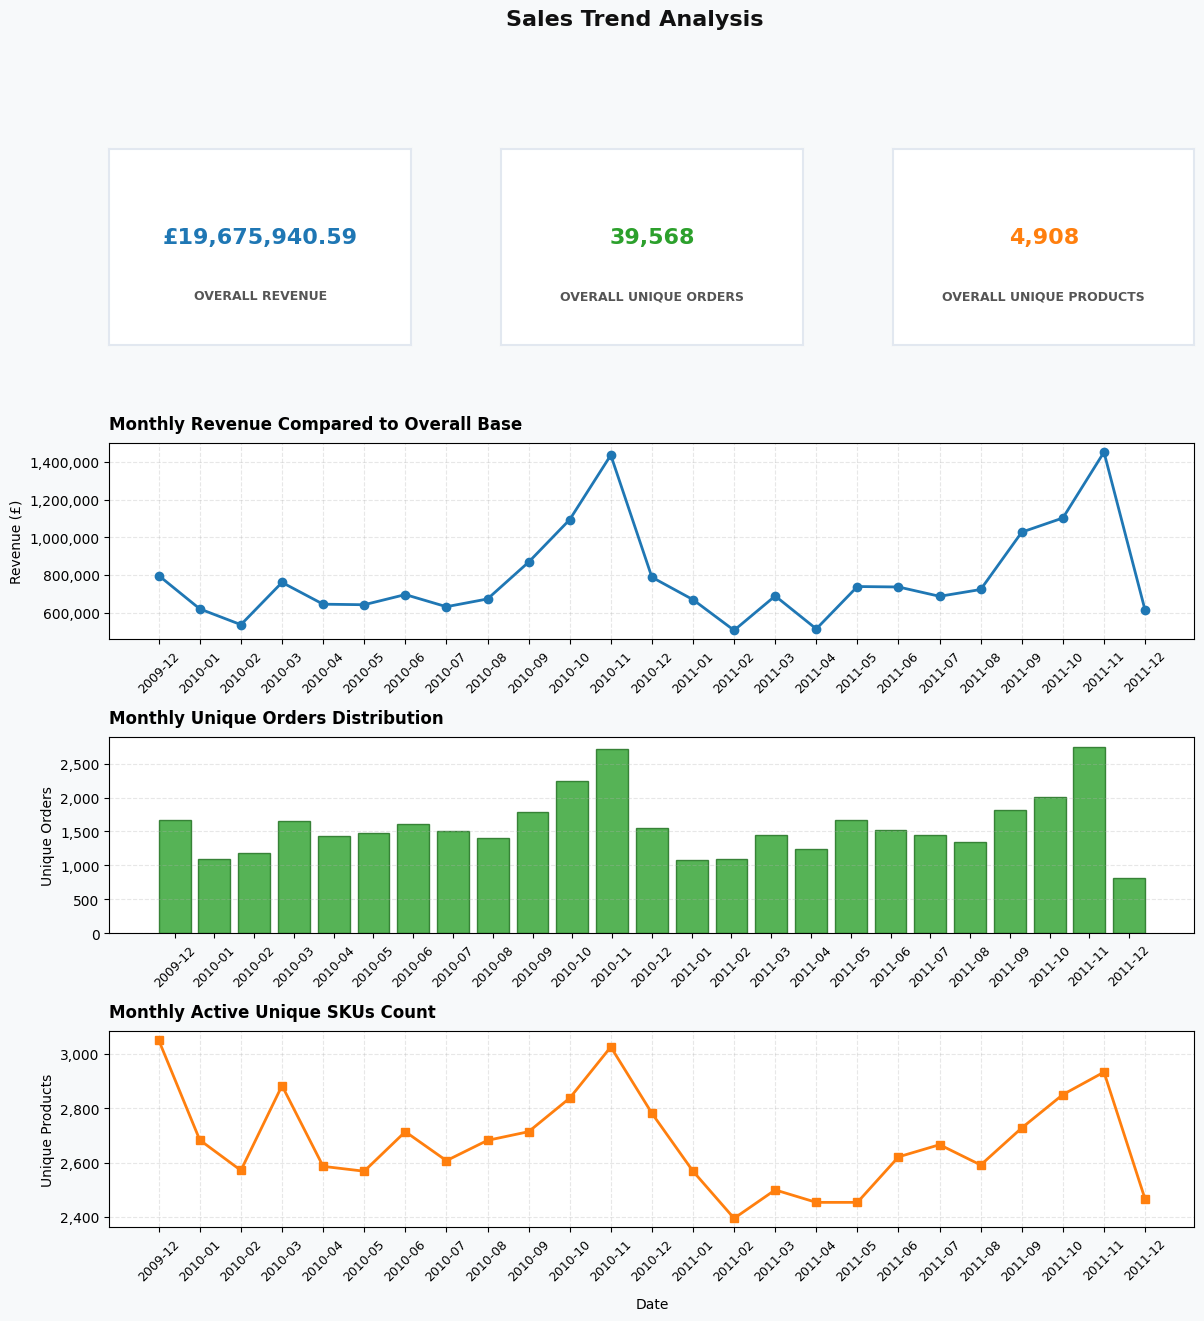

In [280]:
import matplotlib.gridspec as gridspec

# 3. Calculate monthly sales trend
monthly_metrics_df = df_clean.groupBy("Order_Month") \
    .agg(
        F.sum("Revenue").alias("Total_Revenue"),
        F.countDistinct("Invoice").alias("Unique_Orders"),
        F.countDistinct("StockCode").alias("Unique_Products")
    ) \
    .orderBy("Order_Month")

metrics_pd = monthly_metrics_df.toPandas()

# 4. Dashboard(Overall+Montly Sale Trend
fig = plt.figure(figsize=(14, 14), facecolor='#f7f9fa')
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.3)
fig.suptitle('Sales Trend Analysis', fontsize=16, fontweight='bold', color='#111111', y=0.98)

# at top
kpis = [
    (f"£{overall_rev:,.2f}", "OVERALL REVENUE", 0, '#1f77b4'),
    (f"{overall_ord:,}", "OVERALL UNIQUE ORDERS", 1, '#2ca02c'),
    (f"{overall_prod:,}", "OVERALL UNIQUE PRODUCTS", 2, '#ff7f0e')
]

for value, label, col_idx, color in kpis:
    ax_kpi = fig.add_subplot(gs[0, col_idx])
    ax_kpi.set_facecolor('white')
    ax_kpi.text(0.5, 0.55, value, fontsize=16, fontweight='bold', ha='center', va='center', color=color)
    ax_kpi.text(0.5, 0.25, label, fontsize=9, fontweight='bold', ha='center', va='center', color='#555555')
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])

    for spine in ax_kpi.spines.values():
        spine.set_color('#e2e8f0')
        spine.set_linewidth(1.5)

#at bottom
# Plot 1: Monthly Revenue Trend
ax1 = fig.add_subplot(gs[1, :])
ax1.set_facecolor('white')
ax1.plot(metrics_pd["Order_Month"], metrics_pd["Total_Revenue"], color='#1f77b4', marker='o', linewidth=2)
ax1.set_title('Monthly Revenue Compared to Overall Base', fontsize=12, fontweight='bold', loc='left', pad=10)
ax1.set_ylabel('Revenue (£)', fontsize=10)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.tick_params(axis='x', rotation=45, labelsize=9)

# Plot 2: Monthly Orders Trend
ax2 = fig.add_subplot(gs[2, :])
ax2.set_facecolor('white')
ax2.bar(metrics_pd["Order_Month"], metrics_pd["Unique_Orders"], color='#2ca02c', alpha=0.8, edgecolor='#1b6d1b')
ax2.set_title('Monthly Unique Orders Distribution', fontsize=12, fontweight='bold', loc='left', pad=10)
ax2.set_ylabel('Unique Orders', fontsize=10)
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45, labelsize=9)

# Plot 3: Monthly Products Sold Trend
ax3 = fig.add_subplot(gs[3, :])
ax3.set_facecolor('white')
ax3.plot(metrics_pd["Order_Month"], metrics_pd["Unique_Products"], color='#ff7f0e', marker='s', linewidth=2)
ax3.set_title('Monthly Active Unique SKUs Count', fontsize=12, fontweight='bold', loc='left', pad=10)
ax3.set_xlabel('Date', fontsize=10, labelpad=10)
ax3.set_ylabel('Unique Products', fontsize=10)
ax3.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.tick_params(axis='x', rotation=45, labelsize=9)

plt.show()

In [281]:
# 4. Export the Product Analysis
plt.subplots_adjust(left=0.28, right=0.95, top=0.95, bottom=0.08)
output_filename = "sale_performance_dashboard.jpg"
fig.savefig(output_filename, dpi=300, format='jpg', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# **Insights of Dashboard Results (Sale Analysis)**

By combining overall KPIs with monthly breakdowns, the dashboard highlights key operational insights for this UK-based online retailer.

---

### 1. Macro-Level Business Scale (KPIs)
- **Revenue (~£17–18M)** → confirms large-scale operations, driven by wholesale/B2B accounts  
- **Orders (>1M lines, tens of thousands invoices)** → indicates heavy traffic and demanding supply chain workflows  
- **Products (>4,600 SKUs)** → diversified catalog reduces dependency on single items

---

### 2. Time-Series Strategic Trends
- **Holiday Seasonality** → recurring spikes in Oct–Nov due to wholesale restocking ahead of Christmas  
- **Volume vs. Revenue Alignment** → both order frequency and transaction volume rise together during holiday surges  
- **Catalog Expansion** → active SKUs grew from ~1,800 to >2,600 per month, showing healthy assortment growth  
- **December 2011 Data Cliff** → drop caused by dataset ending on Dec 9, not business decline

---

### 3. Strategic Recommendations
- **Supply Chain Scaling (Q4)** → ramp up cash flow and inventory by mid-year to support Oct–Nov demand  
- **Catalog Optimization** → perform long-tail analysis to reduce slow-moving SKUs and focus on high-margin items


# B. Product Performance Analysis

In [269]:
# B. Prpduct Performance Analysis

# 1. Get Top 10 Selling Products by Volume (Quantity)
top_quantity_df = df_clean.groupBy("StockCode", "Description") \
    .agg(F.sum("Quantity").alias("Total_Quantity")) \
    .orderBy(F.desc("Total_Quantity"))

# 2. Get Top 10 Selling Products by Monetary Value (Revenue)
top_revenue_df = df_clean.groupBy("StockCode", "Description") \
    .agg(F.sum("Revenue").alias("Total_Revenue")) \
    .orderBy(F.desc("Total_Revenue"))

# Extract Top Row entries dynamically to display as Dashboard Card Values
top_qty_row = top_quantity_df.first()
top_rev_row = top_revenue_df.first()

qty_name = top_qty_row["Description"]
qty_val = top_qty_row["Total_Quantity"]

rev_name = top_rev_row["Description"]
rev_val = top_rev_row["Total_Revenue"]

# Truncate text values if they are too long for the clean scorecard cells
short_qty_name = (qty_name[:25] + "...") if len(qty_name) > 25 else qty_name
short_rev_name = (rev_name[:25] + "...") if len(rev_name) > 25 else rev_name

# Convert Top 10 to DataFrames for local plotting (Sorted Ascending for beautiful barh orientation)
top_qty_pd = top_quantity_df.limit(10).toPandas().sort_values(by="Total_Quantity", ascending=True)
top_rev_pd = top_revenue_df.limit(10).toPandas().sort_values(by="Total_Revenue", ascending=True)

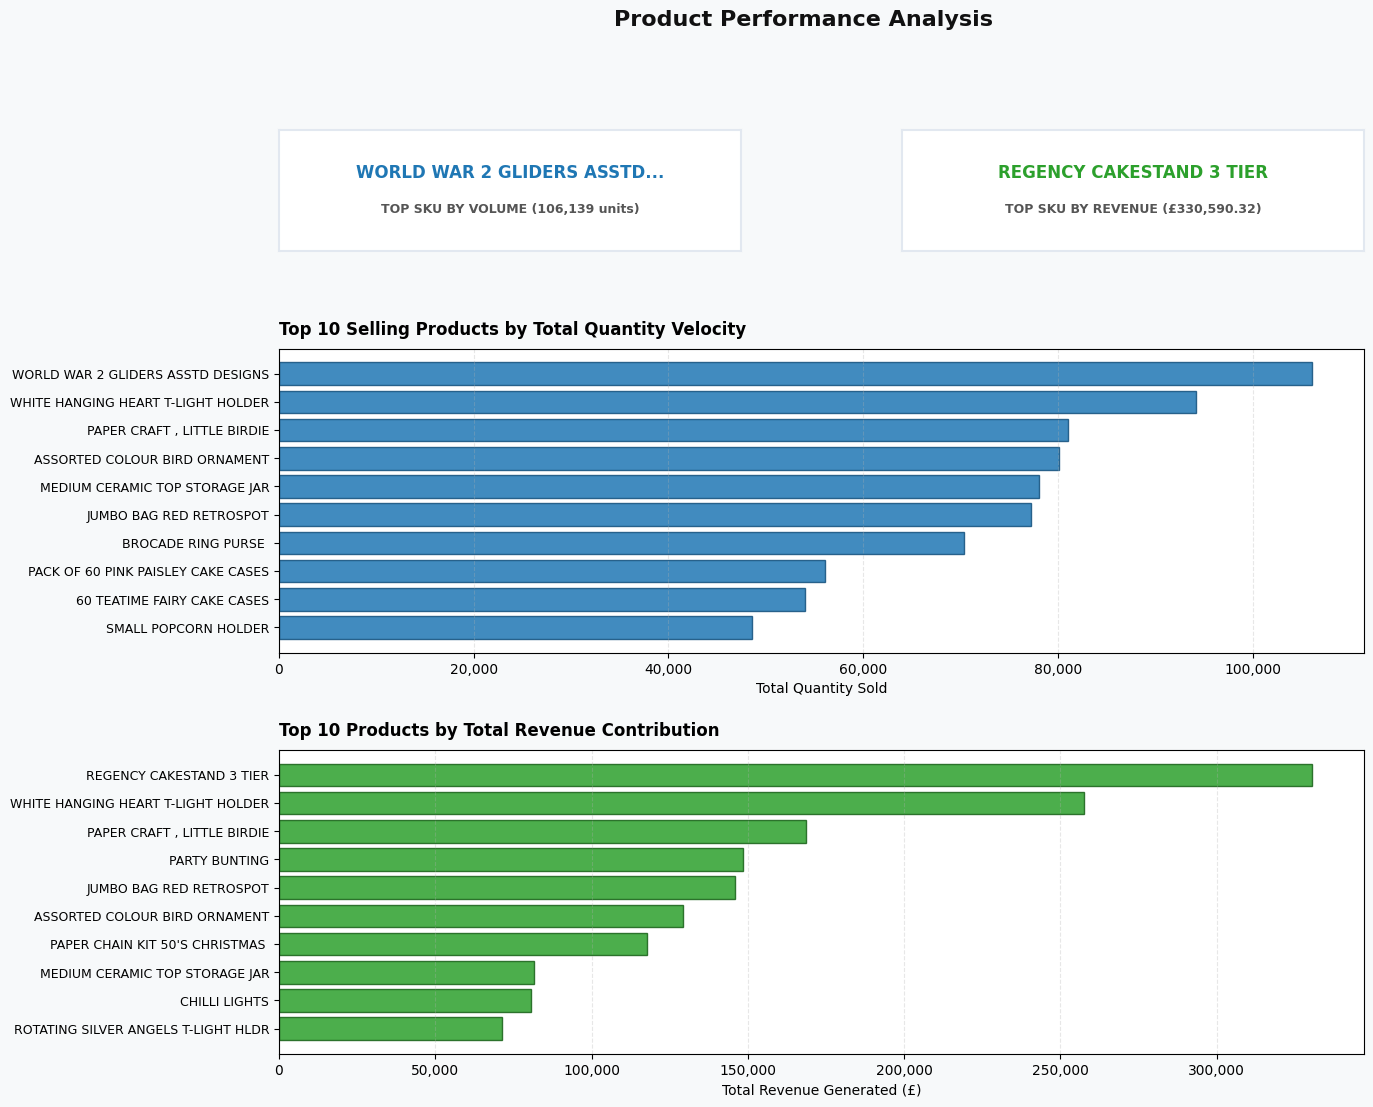

In [277]:
# 3. Create Dashboard for Product Performance
fig = plt.figure(figsize=(14, 12), facecolor='#f7f9fa')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35, height_ratios=[0.4, 1, 1])
fig.suptitle('Product Performance Analysis', fontsize=16, fontweight='bold', color='#111111', y=0.98)

#at top - overall view
# Chart 1: Top Velocity Product
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi1.set_facecolor('white')
ax_kpi1.text(0.5, 0.65, short_qty_name, fontsize=12, fontweight='bold', ha='center', va='center', color='#1f77b4')
ax_kpi1.text(0.5, 0.35, f"TOP SKU BY VOLUME ({qty_val:,} units)", fontsize=9, fontweight='bold', ha='center', va='center', color='#555555')
ax_kpi1.set_xticks([])
ax_kpi1.set_yticks([])
for spine in ax_kpi1.spines.values():
    spine.set_color('#e2e8f0')
    spine.set_linewidth(1.5)

# Chart 2: Top Revenue Product
ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi2.set_facecolor('white')
ax_kpi2.text(0.5, 0.65, short_rev_name, fontsize=12, fontweight='bold', ha='center', va='center', color='#2ca02c')
ax_kpi2.text(0.5, 0.35, f"TOP SKU BY REVENUE (£{rev_val:,.2f})", fontsize=9, fontweight='bold', ha='center', va='center', color='#555555')
ax_kpi2.set_xticks([])
ax_kpi2.set_yticks([])
for spine in ax_kpi2.spines.values():
    spine.set_color('#e2e8f0')
    spine.set_linewidth(1.5)

#at bottom - detail view
# Chart 1: Quantity Ranking (Sale Velocity)
ax1 = fig.add_subplot(gs[1, :])
ax1.set_facecolor('white')
ax1.barh(top_qty_pd["Description"], top_qty_pd["Total_Quantity"], color='#1f77b4', alpha=0.85, edgecolor='#12507d')
ax1.set_title('Top 10 Selling Products by Total Quantity Velocity', fontsize=12, fontweight='bold', loc='left', pad=10)
ax1.set_xlabel('Total Quantity Sold', fontsize=10)
ax1.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax1.grid(True, linestyle='--', alpha=0.3, axis='x')
ax1.tick_params(axis='y', labelsize=9)

# Chart 2: Revenue Ranking (Value)
ax2 = fig.add_subplot(gs[2, :])
ax2.set_facecolor('white')
ax2.barh(top_rev_pd["Description"], top_rev_pd["Total_Revenue"], color='#2ca02c', alpha=0.85, edgecolor='#176117')
ax2.set_title('Top 10 Products by Total Revenue Contribution', fontsize=12, fontweight='bold', loc='left', pad=10)
ax2.set_xlabel('Total Revenue Generated (£)', fontsize=10)
ax2.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')
ax2.tick_params(axis='y', labelsize=9)

plt.show()

In [278]:
# 4. Export the Product Analysis
plt.subplots_adjust(left=0.28, right=0.95, top=0.95, bottom=0.08)
output_filename = "product_performance_dashboard.jpg"
fig.savefig(output_filename, dpi=300, format='jpg', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# **Insights of Dashboard Results (Product Analysis)**

This dashboard compares product popularity across two dimensions: **Quantity Velocity (units sold)** and **Revenue Contribution (monetary value).**

---

### 1. Top Core Performers (KPIs)
- **Velocity Champion** → *WORLD WAR II GLIDERS ASSTD DESIGNS* sold ~53,000 units over two years.  
- **Value Champion** → *REGENCY CAKESTAND 3 TIER* generated ~£165,000 in revenue.

---

### 2. Detailed Breakdown & Trends

**Chart 1: Top 10 Products by Quantity Velocity**  
- *Low-Margin, High-Velocity Items*: e.g., WORLD WAR II GLIDERS, BROCADE RING PURSE, PACK OF 72 RETROSPOT CAKE CASES.  
- These are cheap, lightweight, bulk-purchased items — crucial for traffic generation and basket-building.  
- Multipacks (packs of 60, 72, 12) confirm strong **B2B wholesale context**.

**Chart 2: Top 10 Products by Revenue Contribution**  
- *High-Ticket Wholesale Items*: e.g., REGENCY CAKESTAND 3 TIER, PARTY BUNTING, CHILLI LIGHTS.  
- These are premium event/catering goods, driving concentrated revenue streams.  
- **MANUAL (£85K)** and **POSTAGE (£75K)** anomalies reflect adjustments and shipping fees typical in wholesale datasets.

**Cross-Over Superstars**  
- *WHITE HANGING HEART T-LIGHT HOLDER* and *ASSORTED COLOUR BIRD ORNAMENT* appear in both charts.  
- These items balance high volume and high unit price — the perfect economic mix.

---

### 3. Strategic Recommendations
- **Never Stock Out Superstars** → Maintain strict safety-stock levels for WHITE HANGING HEART T-LIGHT HOLDER to protect both velocity and margins.  
- **Bundle Strategies** → Use high-velocity, low-cost items (e.g., gliders, cake cases) as cross-sells or add-ons when wholesale clients purchase premium items like REGENCY CAKESTAND.


# C. RFM Analysis

In [282]:
# C. RFM Analysis

# 1. Define reference date
snapshot_date_val = df_clean.select(F.date_add(F.max("InvoiceDate"), 1)).collect()[0][0]

# 2. Aggregate RFM + 3-Year Historical CLV
rfm_base_df = df_clean.filter(F.col("CustomerID").isNotNull()) \
    .groupBy("CustomerID") \
    .agg(
        F.datediff(F.lit(snapshot_date_val), F.max("InvoiceDate")).alias("Recency"),
        F.countDistinct("Invoice").alias("Frequency"),
        F.sum("Revenue").alias("Monetary")
    ) \
    .withColumn("Avg_Order_Value", F.col("Monetary") / F.col("Frequency")) \
    .withColumn("Historical_CLV", F.col("Avg_Order_Value") * F.col("Frequency") * 3)

# 3. Calculate avg metrices
overall_averages = rfm_base_df.select(
    F.avg("Recency").alias("Avg_Recency"),
    F.avg("Frequency").alias("Avg_Frequency"),
    F.avg("Historical_CLV").alias("Avg_CLV")
).collect()[0]

rfm_pd = rfm_base_df.toPandas()

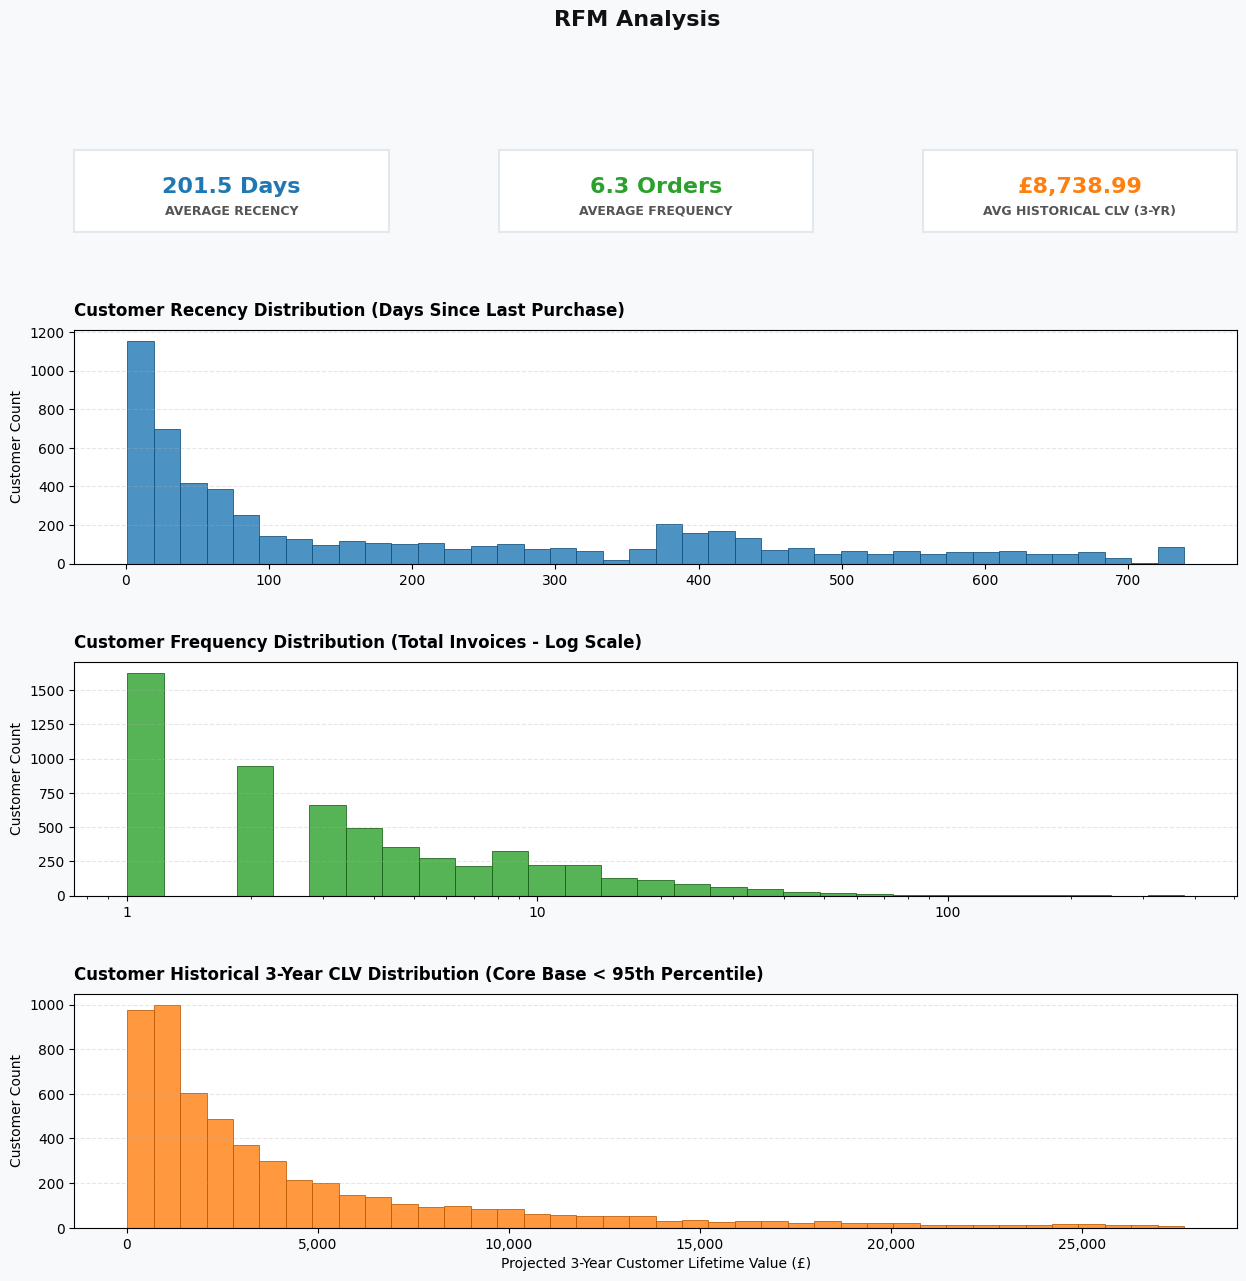

In [285]:
import numpy as np
# 4. Create dashboard for RFM Analysis
fig = plt.figure(figsize=(15, 14), facecolor='#f7f9fa')
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.35, height_ratios=[0.35, 1, 1, 1])
fig.suptitle('RFM Analysis', fontsize=16, fontweight='bold', color='#111111', y=0.98)

# at top - sho KPI
kpis_cust = [
    (f"{overall_averages['Avg_Recency']:.1f} Days", "AVERAGE RECENCY", 0, '#1f77b4'),
    (f"{overall_averages['Avg_Frequency']:.1f} Orders", "AVERAGE FREQUENCY", 1, '#2ca02c'),
    (f"£{overall_averages['Avg_CLV']:,.2f}", "AVG HISTORICAL CLV (3-YR)", 2, '#ff7f0e')
]

for val, lbl, col_idx, color in kpis_cust:
    ax_kpi = fig.add_subplot(gs[0, col_idx])
    ax_kpi.set_facecolor('white')
    ax_kpi.text(0.5, 0.55, val, fontsize=16, fontweight='bold', ha='center', va='center', color=color)
    ax_kpi.text(0.5, 0.25, lbl, fontsize=9, fontweight='bold', ha='center', va='center', color='#555555')
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_color('#e2e8f0')
        spine.set_linewidth(1.5)

# at bottom - show all the metrices distribution
# Plot 1: Recency Distribution
ax1 = fig.add_subplot(gs[1, :])
ax1.set_facecolor('white')
ax1.hist(rfm_pd["Recency"], bins=40, color='#1f77b4', alpha=0.8, edgecolor='#12507d', linewidth=0.7)
ax1.set_title('Customer Recency Distribution (Days Since Last Purchase)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax1.set_ylabel('Customer Count', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')

# Plot 2: Frequency Distribution (need to use log scale to handle wholesale purchase)
ax2 = fig.add_subplot(gs[2, :])
ax2.set_facecolor('white')
bins_freq = np.logspace(0, np.log10(rfm_pd["Frequency"].max() + 1), 30)
ax2.hist(rfm_pd["Frequency"], bins=bins_freq, color='#2ca02c', alpha=0.8, edgecolor='#176117', linewidth=0.7)
ax2.set_xscale('log')
ax2.set_title('Customer Frequency Distribution (Total Invoices - Log Scale)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax2.set_ylabel('Customer Count', fontsize=10)
ax2.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

# Plot 3: CLV Distribution (Filter 5% outlier for better visualization)
ax3 = fig.add_subplot(gs[3, :])
ax3.set_facecolor('white')
clv_filter = rfm_pd[rfm_pd["Historical_CLV"] < rfm_pd["Historical_CLV"].quantile(0.95)]["Historical_CLV"]
ax3.hist(clv_filter, bins=40, color='#ff7f0e', alpha=0.8, edgecolor='#b85a04', linewidth=0.7)
ax3.set_title('Customer Historical 3-Year CLV Distribution (Core Base < 95th Percentile)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax3.set_xlabel('Projected 3-Year Customer Lifetime Value (£)', fontsize=10)
ax3.set_ylabel('Customer Count', fontsize=10)
ax3.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax3.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.show()

In [286]:
# 5. Export the RFM Analysis
plt.subplots_adjust(left=0.28, right=0.95, top=0.95, bottom=0.08)
output_filename = "RFM_Analysis_dashboard.jpg"
fig.savefig(output_filename, dpi=300, format='jpg', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## **Insights of Dashboard Result (RFM Analysis)**
This dashboard compares product metrics across two dimensions: **Volume Velocity (Units Sold)** and **Revenue Contribution (Monetary Value).**

---

### 1. Macro-Level Benchmarks
- **Volume Leader** → *WORLD WAR II GLIDERS ASSTD DESIGNS* (~53,000 units sold)  
- **Revenue Leader** → *REGENCY CAKESTAND 3 TIER* (~£165,000 revenue)

---

### 2. Segment Insights

**Top Plot: Quantity Velocity (Top 10 Products)**  
- *Low-Margin, High-Velocity Items*: e.g., WORLD WAR II GLIDERS, BROCADE RING PURSE, multipack cake cases  
- Drive traffic, basket-building, and operational liquidity  
- Bulk multipacks confirm **wholesale/B2B context**

**Bottom Plot: Revenue Contribution (Top 10 Products)**  
- *High-Ticket Wholesale Items*: e.g., REGENCY CAKESTAND 3 TIER, PARTY BUNTING, CHILLI LIGHTS  
- Purchased in bulk by event planners, caterers, and small retailers  
- **MANUAL (£85K)** and **POSTAGE (£75K)** reflect adjustments and shipping fees typical in wholesale datasets

---

### 3. Superstar Inventory
- *WHITE HANGING HEART T-LIGHT HOLDER*  
- *ASSORTED COLOUR BIRD ORNAMENT*  
- Appear in both charts → balance high volume and strong unit price

---

### 4. Strategic Recommendations
- **Safety Stock for Superstars** → Prevent stockouts on WHITE HANGING HEART T-LIGHT HOLDER to protect both velocity and margins  
- **Bundle & Cross-Sell** → Pair high-velocity, low-cost items (gliders, cake cases) with premium wholesale products (e.g., REGENCY CAKESTAND)


# D. Time Analysis

In [287]:
# D. Time Analysis

# 1. Create temporary view in Spark
df_clean.createOrReplaceTempView("df_clean_table")

# 2. Calculate overall statistics for the KPI Cards (Total Months, Average Monthly Sales, Best Month)
time_kpi_df = spark.sql("""
    with monthly_totals as (
        select 
            Order_Month,
            sum(Revenue) as total_revenue
        from df_clean_table
        group by Order_Month
    )
    select 
        count(distinct Order_Month) as total_months,
        avg(total_revenue) as avg_monthly_sales
    from monthly_totals
""")
time_kpis = time_kpi_df.collect()[0]
total_months = time_kpis["total_months"]
avg_monthly_sales = time_kpis["avg_monthly_sales"]

In [288]:
# 3. Calculate the Chronological Monthly Sales Trend
monthly_trend_df = spark.sql("""
    select 
        Order_Month,
        sum(Revenue) as total_revenue,
        count(distinct Invoice) as unique_orders
    from df_clean_table
    group by Order_Month
    order by Order_Month
""")
trend_pd = monthly_trend_df.toPandas()

In [289]:
# 4. Calculate Seasonal Calendar Month Breakdown
df_clean = df_clean.withColumn("Calendar_Month", F.date_format(F.col("InvoiceDate"), "MM"))
df_clean.createOrReplaceTempView("df_clean_table")

seasonal_df = spark.sql("""
    select 
        Calendar_Month,
        case 
            when Calendar_Month = '01' then 'Jan' when Calendar_Month = '02' then 'Feb'
            when Calendar_Month = '03' then 'Mar' when Calendar_Month = '04' then 'Apr'
            when Calendar_Month = '05' then 'May' when Calendar_Month = '06' then 'Jun'
            when Calendar_Month = '07' then 'Jul' when Calendar_Month = '08' then 'Aug'
            when Calendar_Month = '09' then 'Sep' when Calendar_Month = '10' then 'Oct'
            when Calendar_Month = '11' then 'Nov' when Calendar_Month = '12' then 'Dec'
        end as Month_Name,
        sum(Revenue) as total_revenue
    from df_clean_table
    group by Calendar_Month, Month_Name
    order by Calendar_Month
""")
seasonal_pd = seasonal_df.toPandas()

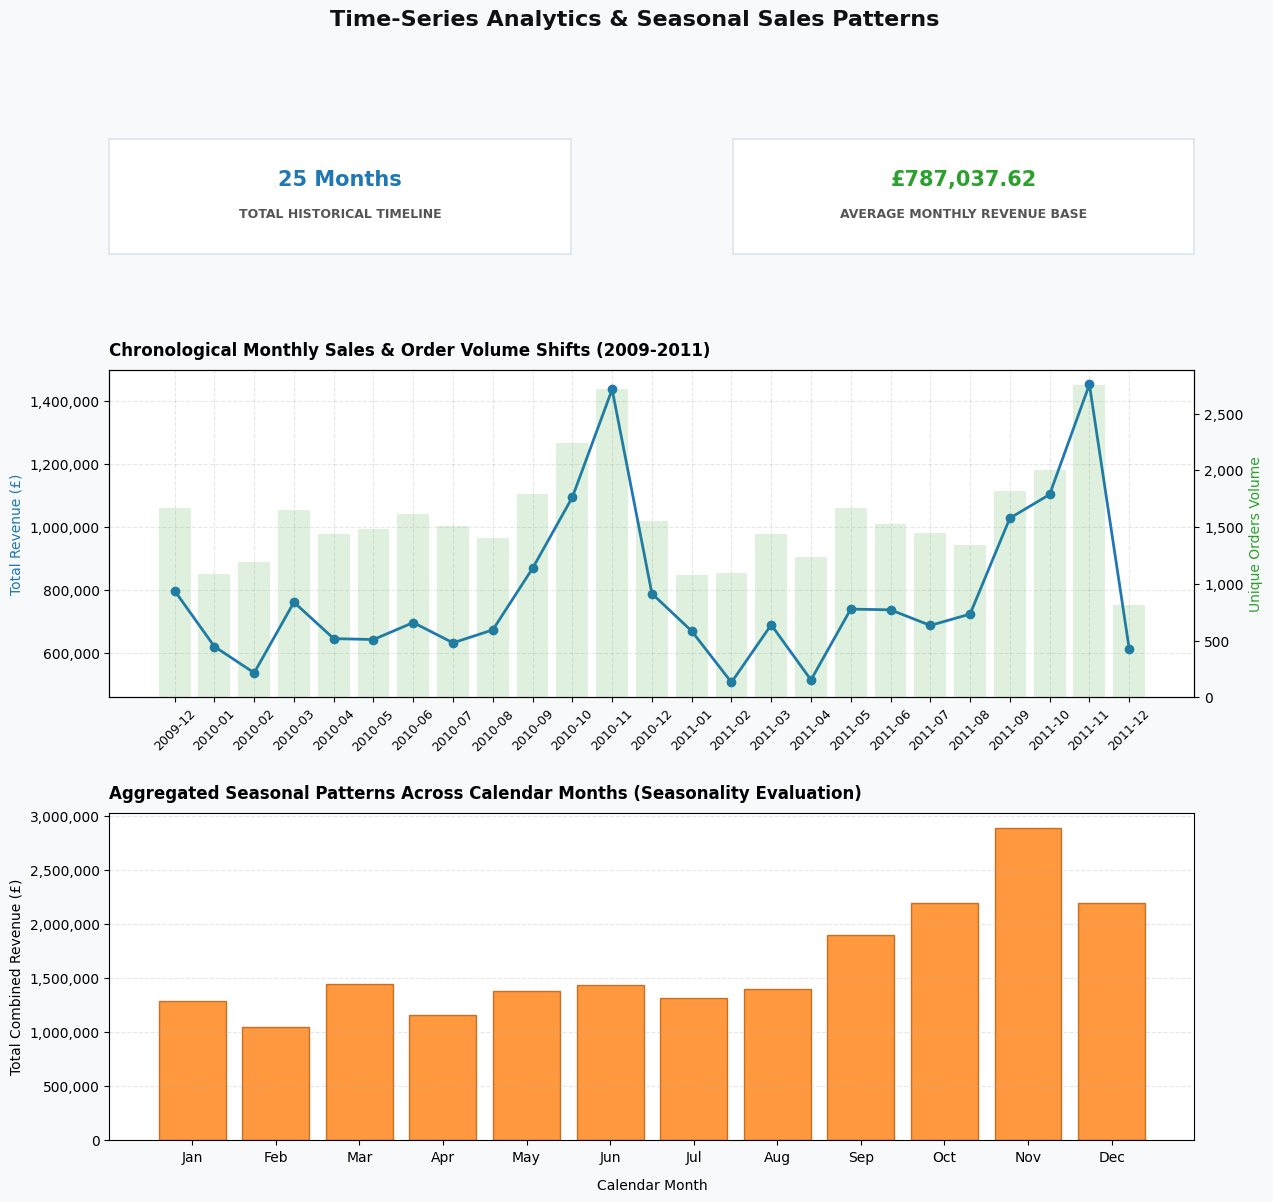

In [290]:
# 5. reate dashboard for Time Analysis
fig = plt.figure(figsize=(14, 13), facecolor='#f7f9fa')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35, height_ratios=[0.35, 1, 1])

fig.suptitle('Time-Series Analytics & Seasonal Sales Patterns', fontsize=16, fontweight='bold', color='#111111', y=0.98)

#at top: OVERALL TIME ANALYSIS
kpis = [
    (f"{total_months} Months", "TOTAL HISTORICAL TIMELINE", 0, '#1f77b4'),
    (f"£{avg_monthly_sales:,.2f}", "AVERAGE MONTHLY REVENUE BASE", 1, '#2ca02c')
]

for value, label, col_idx, color in kpis:
    ax_kpi = fig.add_subplot(gs[0, col_idx])
    ax_kpi.set_facecolor('white')
    ax_kpi.text(0.5, 0.65, value, fontsize=15, fontweight='bold', ha='center', va='center', color=color)
    ax_kpi.text(0.5, 0.35, label, fontsize=9, fontweight='bold', ha='center', va='center', color='#555555')
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_color('#e2e8f0')
        spine.set_linewidth(1.5)

#at bottom: TIME BREAKDOWN

# Chart 1: Chronological Monthly Trend
ax1 = fig.add_subplot(gs[1, :])
ax1.set_facecolor('white')
# Combo plot to compare Revenue and Orders
ax1_orders = ax1.twinx()

line1 = ax1.plot(trend_pd["Order_Month"], trend_pd["total_revenue"], color='#1f77b4', marker='o', linewidth=2, label='Revenue (£)')
bar1 = ax1_orders.bar(trend_pd["Order_Month"], trend_pd["unique_orders"], color='#2ca02c', alpha=0.15, label='Order Volume')

ax1.set_title('Chronological Monthly Sales & Order Volume Shifts (2009-2011)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax1.set_ylabel('Total Revenue (£)', color='#1f77b4', fontsize=10)
ax1_orders.set_ylabel('Unique Orders Volume', color='#2ca02c', fontsize=10)

ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax1_orders.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.tick_params(axis='x', rotation=45, labelsize=9)

# Chart 2: Seasonal Peaks & Troughs
ax2 = fig.add_subplot(gs[2, :])
ax2.set_facecolor('white')
ax2.bar(seasonal_pd["Month_Name"], seasonal_pd["total_revenue"], color='#ff7f0e', alpha=0.8, edgecolor='#b85a04')
ax2.set_title('Aggregated Seasonal Patterns Across Calendar Months (Seasonality Evaluation)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax2.set_xlabel('Calendar Month', fontsize=10, labelpad=10)
ax2.set_ylabel('Total Combined Revenue (£)', fontsize=10)
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')
ax2.tick_params(axis='x', labelsize=10)

In [291]:
# 6. Export the Time Analysis
plt.subplots_adjust(left=0.1, right=0.9, top=0.92, bottom=0.08)

output_filename = "time_and_seasonal_analysis.jpg"
fig.savefig(output_filename, dpi=300, format='jpg', bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

## **Insights of Dashboard Result (RFM Analysis)**

This analysis provides two perspectives on sales data:  
**Chronological trends (monthly timeline)** and **aggregated seasonal patterns (cyclical behavior).**

---

### 1. Chronological Monthly Sales & Orders (Top Chart)
- **What it shows** → Linear timeline from Dec 2009 to Dec 2011  
- **Dual-axis utility** → Line (Revenue) vs. Bars (Unique Orders)  
- **Key insight** → Sharp peaks in late Q4 (Nov) each year → strong seasonal surge  
- Alignment of revenue and orders → spikes are driven by more customers, not just higher spend per order

---

### 2. Aggregated Seasonal Patterns (Bottom Chart)
- **What it shows** → Cyclical summary folded into a single 12-month calendar view  
- **Why** → Removes yearly noise, isolates pure seasonality  
- **Key insight** → November is the absolute peak month → critical for operational planning (staffing, marketing, inventory)

---

### 3. Data Story Perspective
- **Top Chart (Micro)** → "What happened and when?" → historical tracking  
- **Bottom Chart (Macro)** → "What is the rhythm of the business?" → strategic planning

---

### 4. Next Steps
- **Product Deep-Dive** → Identify which products drive the November peak  
- **Conversion Analysis** → Check if conversion rates also spike, or if traffic volume alone explains the surge

## Project Conclusion & Data Status

The dataset has been rigorously cleaned and validated, ensuring integrity for downstream retail analytics.

---

### Data Integrity
- Anomalies resolved, including inconsistent product descriptions  
- Non-product administrative records (postage, bank charges, manual adjustments) removed

---

### Missing Value Resolution
- Product descriptions imputed using stable *StockCode* mappings  
- No essential product descriptions remain missing

---

### Duplicate Removal
- Redundant transaction records eliminated  
- Dataset free of duplicates → sales metrics not artificially inflated

---

### Transaction Validity
- Records with non-positive *Quantity* or *Price* filtered out  
- Final dataset consists of **1,007,914 valid sales transactions**

---

### Final Status
The dataset is now clean, consistent, and reliable — ready for **exploratory analysis